# Cause of Unfairness - Method Analysis
## CSC4009 Assignment 1

This notebook analyzes how different classifier settings impact fairness metrics.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [ ]:
# Load and preprocess the dataset
data = pd.read_csv('CSC4009-AI-Fairness-datasets/adult.data.csv', na_values='?').dropna()

# Reset index after dropping NA values
data = data.reset_index(drop=True)

# Encode categorical features using OrdinalEncoder (consistent with other scripts)
data_encoded = data.copy()
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation', 
                    'relationship', 'race', 'sex', 'native-country', 'income-class']
enc = OrdinalEncoder()
data_encoded[categorical_cols] = enc.fit_transform(data_encoded[categorical_cols])

# Prepare features - exclude protected attributes and fnlwgt from model features
# Feature mask: age, workclass, fnlwgt, education, education-num, marital-status, occupation,
#               relationship, race, sex, capital-gain, capital-loss, hours-per-week, native-country
#               T     T        F       T          T            F             T
#               F           F     F      T             T            T            F
feature_mask = [True, True, False, True, True, False, True, False, False, False, True, True, True, False]
X = data_encoded.iloc[:, [i for i, m in enumerate(feature_mask) if m]]
y = data_encoded['income-class']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Store protected attributes for test set (use .loc with the index)
sex_test = data.loc[X_test.index, 'sex'].values
race_test = data.loc[X_test.index, 'race'].values

print(f"Training set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")

Training set: 24,129 samples
Test set: 6,033 samples


In [4]:
def calculate_group_fairness(y_true, y_pred, protected_attr):
    """
    Calculate fairness metrics for each group in a protected attribute.
    Returns: dict with accuracy, TPR, and selection rate per group
    """
    results = {}
    unique_groups = np.unique(protected_attr)
    
    for group in unique_groups:
        mask = protected_attr == group
        y_true_group = y_true[mask]
        y_pred_group = y_pred[mask]
        
        # Accuracy
        accuracy = accuracy_score(y_true_group, y_pred_group) * 100
        
        # TPR (True Positive Rate) = TP / (TP + FN)
        positives = y_true_group == 1
        if positives.sum() > 0:
            tpr = (y_pred_group[positives] == 1).sum() / positives.sum() * 100
        else:
            tpr = 0
        
        # Selection Rate = predicted positive / total
        selection_rate = (y_pred_group == 1).sum() / len(y_pred_group) * 100
        
        results[group] = {
            'accuracy': accuracy,
            'tpr': tpr,
            'selection_rate': selection_rate,
            'count': len(y_true_group)
        }
    
    return results

def calculate_disparity(group_metrics):
    """
    Calculate maximum disparity (max - min) for each metric across groups.
    """
    accuracies = [m['accuracy'] for m in group_metrics.values()]
    tprs = [m['tpr'] for m in group_metrics.values()]
    selection_rates = [m['selection_rate'] for m in group_metrics.values()]
    
    return {
        'accuracy_disparity': max(accuracies) - min(accuracies),
        'tpr_disparity': max(tprs) - min(tprs),
        'selection_rate_disparity': max(selection_rates) - min(selection_rates)
    }

print("Fairness calculation functions defined.")

Fairness calculation functions defined.


---
## Experiment 1: Different Classifiers

In [5]:
# Define all classifier configurations
classifiers = {
    # KNN variants
    'KNN (k=3)': KNeighborsClassifier(n_neighbors=3, n_jobs=-1),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'KNN (k=10)': KNeighborsClassifier(n_neighbors=10, n_jobs=-1),
    
    # Decision Tree variants
    'DecisionTree (depth=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'DecisionTree (depth=10)': DecisionTreeClassifier(max_depth=10, random_state=42),
    'DecisionTree (depth=None)': DecisionTreeClassifier(max_depth=None, random_state=42),
    
    # Random Forest variants
    'RandomForest (n=50)': RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    'RandomForest (n=100)': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

print(f"Testing {len(classifiers)} classifier configurations...")

Testing 8 classifier configurations...


In [6]:
# Run experiments for all classifiers
results = []

for name, clf in classifiers.items():
    print(f"Training {name}...", end=" ")
    
    # Train and predict
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # Overall accuracy
    overall_acc = accuracy_score(y_test, y_pred) * 100
    
    # Sex fairness
    sex_metrics = calculate_group_fairness(y_test.values, y_pred, sex_test)
    sex_disparity = calculate_disparity(sex_metrics)
    
    # Race fairness
    race_metrics = calculate_group_fairness(y_test.values, y_pred, race_test)
    race_disparity = calculate_disparity(race_metrics)
    
    results.append({
        'Configuration': name,
        'Overall Accuracy': overall_acc,
        'Sex Acc Disparity': sex_disparity['accuracy_disparity'],
        'Sex TPR Disparity': sex_disparity['tpr_disparity'],
        'Race Acc Disparity': race_disparity['accuracy_disparity'],
        'Race TPR Disparity': race_disparity['tpr_disparity'],
        'Avg Disparity': (sex_disparity['tpr_disparity'] + race_disparity['tpr_disparity']) / 2,
        # Store detailed metrics for later
        '_sex_metrics': sex_metrics,
        '_race_metrics': race_metrics
    })
    
    print(f"Accuracy: {overall_acc:.2f}%")

print("\nAll classifiers trained successfully!")

Training KNN (k=3)... Accuracy: 75.39%
Training KNN (k=5)... Accuracy: 76.16%
Training KNN (k=10)... Accuracy: 78.47%
Training DecisionTree (depth=5)... Accuracy: 84.58%
Training DecisionTree (depth=10)... Accuracy: 85.50%
Training DecisionTree (depth=None)... Accuracy: 80.89%
Training RandomForest (n=50)... Accuracy: 85.40%
Training RandomForest (n=100)... Accuracy: 85.53%

All classifiers trained successfully!


In [7]:
# Create results DataFrame
df_results = pd.DataFrame(results)
display_cols = ['Configuration', 'Overall Accuracy', 'Sex Acc Disparity', 'Sex TPR Disparity', 
                'Race Acc Disparity', 'Race TPR Disparity', 'Avg Disparity']

print("=" * 100)
print("EXPERIMENT 1: CLASSIFIER COMPARISON RESULTS")
print("=" * 100)
print("\n(All disparity values are in percentage points)\n")
print(df_results[display_cols].to_string(index=False, float_format='%.2f'))

EXPERIMENT 1: CLASSIFIER COMPARISON RESULTS

(All disparity values are in percentage points)

            Configuration  Overall Accuracy  Sex Acc Disparity  Sex TPR Disparity  Race Acc Disparity  Race TPR Disparity  Avg Disparity
                KNN (k=3)             75.39              12.29               0.46               17.77               50.00          25.23
                KNN (k=5)             76.16              13.93               3.05               16.94               33.33          18.19
               KNN (k=10)             78.47              17.24               6.61               18.26               50.00          28.30
   DecisionTree (depth=5)             84.58              11.51               3.57               12.63               23.25          13.41
  DecisionTree (depth=10)             85.50              10.31               5.42               10.36               28.07          16.75
DecisionTree (depth=None)             80.89              12.22               8.35   

In [8]:
# Identify best/worst configurations
best_accuracy = df_results.loc[df_results['Overall Accuracy'].idxmax()]
best_fairness = df_results.loc[df_results['Avg Disparity'].idxmin()]
worst_fairness = df_results.loc[df_results['Avg Disparity'].idxmax()]

print("\n" + "=" * 70)
print("KEY FINDINGS - EXPERIMENT 1")
print("=" * 70)
print(f"\n🎯 HIGHEST ACCURACY: {best_accuracy['Configuration']}")
print(f"   Accuracy: {best_accuracy['Overall Accuracy']:.2f}%")
print(f"   Avg TPR Disparity: {best_accuracy['Avg Disparity']:.2f} pp")

print(f"\n⚖️ BEST FAIRNESS (Lowest Disparity): {best_fairness['Configuration']}")
print(f"   Accuracy: {best_fairness['Overall Accuracy']:.2f}%")
print(f"   Avg TPR Disparity: {best_fairness['Avg Disparity']:.2f} pp")

print(f"\n⚠️ WORST FAIRNESS (Highest Disparity): {worst_fairness['Configuration']}")
print(f"   Accuracy: {worst_fairness['Overall Accuracy']:.2f}%")
print(f"   Avg TPR Disparity: {worst_fairness['Avg Disparity']:.2f} pp")


KEY FINDINGS - EXPERIMENT 1

🎯 HIGHEST ACCURACY: RandomForest (n=100)
   Accuracy: 85.53%
   Avg TPR Disparity: 8.98 pp

⚖️ BEST FAIRNESS (Lowest Disparity): RandomForest (n=100)
   Accuracy: 85.53%
   Avg TPR Disparity: 8.98 pp

⚠️ WORST FAIRNESS (Highest Disparity): KNN (k=10)
   Accuracy: 78.47%
   Avg TPR Disparity: 28.30 pp


---
## Experiment 2: Class Imbalance Handling

In [9]:
# Classifiers with and without class_weight='balanced'
balanced_experiments = {
    # Decision Tree comparison
    'DecisionTree (default)': DecisionTreeClassifier(max_depth=10, random_state=42),
    'DecisionTree (balanced)': DecisionTreeClassifier(max_depth=10, random_state=42, class_weight='balanced'),
    
    # Random Forest comparison
    'RandomForest (default)': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'RandomForest (balanced)': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'),
}

print("Testing class_weight='balanced' impact...")

Testing class_weight='balanced' impact...


In [10]:
# Run balanced experiments
balanced_results = []

for name, clf in balanced_experiments.items():
    print(f"Training {name}...", end=" ")
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    overall_acc = accuracy_score(y_test, y_pred) * 100
    
    sex_metrics = calculate_group_fairness(y_test.values, y_pred, sex_test)
    sex_disparity = calculate_disparity(sex_metrics)
    
    race_metrics = calculate_group_fairness(y_test.values, y_pred, race_test)
    race_disparity = calculate_disparity(race_metrics)
    
    balanced_results.append({
        'Configuration': name,
        'Overall Accuracy': overall_acc,
        'Sex TPR Disparity': sex_disparity['tpr_disparity'],
        'Sex Selection Disparity': sex_disparity['selection_rate_disparity'],
        'Race TPR Disparity': race_disparity['tpr_disparity'],
        'Race Selection Disparity': race_disparity['selection_rate_disparity'],
        '_sex_metrics': sex_metrics,
        '_race_metrics': race_metrics
    })
    
    print(f"Done")

print("\nAll balanced experiments complete!")

Training DecisionTree (default)... Done
Training DecisionTree (balanced)... Done
Training RandomForest (default)... Done
Training RandomForest (balanced)... Done

All balanced experiments complete!


In [11]:
# Display balanced results
df_balanced = pd.DataFrame(balanced_results)
display_cols_balanced = ['Configuration', 'Overall Accuracy', 'Sex TPR Disparity', 
                         'Sex Selection Disparity', 'Race TPR Disparity', 'Race Selection Disparity']

print("=" * 100)
print("EXPERIMENT 2: CLASS WEIGHT BALANCED COMPARISON")
print("=" * 100)
print("\n(All disparity values are in percentage points)\n")
print(df_balanced[display_cols_balanced].to_string(index=False, float_format='%.2f'))

EXPERIMENT 2: CLASS WEIGHT BALANCED COMPARISON

(All disparity values are in percentage points)

          Configuration  Overall Accuracy  Sex TPR Disparity  Sex Selection Disparity  Race TPR Disparity  Race Selection Disparity
 DecisionTree (default)             85.50               5.42                    18.85               28.07                     17.91
DecisionTree (balanced)             80.13               8.98                    30.90                6.14                     18.70
 RandomForest (default)             85.53               9.22                    19.60                8.75                     17.73
RandomForest (balanced)             85.36               7.01                    18.54               14.68                     16.66


In [12]:
# Calculate the impact of balanced weighting
print("\n" + "=" * 70)
print("IMPACT OF class_weight='balanced'")
print("=" * 70)

# Decision Tree comparison
dt_default = df_balanced[df_balanced['Configuration'] == 'DecisionTree (default)'].iloc[0]
dt_balanced = df_balanced[df_balanced['Configuration'] == 'DecisionTree (balanced)'].iloc[0]

print("\n📊 DECISION TREE:")
print(f"   Accuracy: {dt_default['Overall Accuracy']:.2f}% → {dt_balanced['Overall Accuracy']:.2f}% "
      f"({'↓' if dt_balanced['Overall Accuracy'] < dt_default['Overall Accuracy'] else '↑'} "
      f"{abs(dt_balanced['Overall Accuracy'] - dt_default['Overall Accuracy']):.2f} pp)")
print(f"   Sex TPR Disparity: {dt_default['Sex TPR Disparity']:.2f} → {dt_balanced['Sex TPR Disparity']:.2f} pp "
      f"({'✓ IMPROVED' if dt_balanced['Sex TPR Disparity'] < dt_default['Sex TPR Disparity'] else '✗ WORSENED'})")
print(f"   Race TPR Disparity: {dt_default['Race TPR Disparity']:.2f} → {dt_balanced['Race TPR Disparity']:.2f} pp "
      f"({'✓ IMPROVED' if dt_balanced['Race TPR Disparity'] < dt_default['Race TPR Disparity'] else '✗ WORSENED'})")

# Random Forest comparison
rf_default = df_balanced[df_balanced['Configuration'] == 'RandomForest (default)'].iloc[0]
rf_balanced = df_balanced[df_balanced['Configuration'] == 'RandomForest (balanced)'].iloc[0]

print("\n📊 RANDOM FOREST:")
print(f"   Accuracy: {rf_default['Overall Accuracy']:.2f}% → {rf_balanced['Overall Accuracy']:.2f}% "
      f"({'↓' if rf_balanced['Overall Accuracy'] < rf_default['Overall Accuracy'] else '↑'} "
      f"{abs(rf_balanced['Overall Accuracy'] - rf_default['Overall Accuracy']):.2f} pp)")
print(f"   Sex TPR Disparity: {rf_default['Sex TPR Disparity']:.2f} → {rf_balanced['Sex TPR Disparity']:.2f} pp "
      f"({'✓ IMPROVED' if rf_balanced['Sex TPR Disparity'] < rf_default['Sex TPR Disparity'] else '✗ WORSENED'})")
print(f"   Race TPR Disparity: {rf_default['Race TPR Disparity']:.2f} → {rf_balanced['Race TPR Disparity']:.2f} pp "
      f"({'✓ IMPROVED' if rf_balanced['Race TPR Disparity'] < rf_default['Race TPR Disparity'] else '✗ WORSENED'})")


IMPACT OF class_weight='balanced'

📊 DECISION TREE:
   Accuracy: 85.50% → 80.13% (↓ 5.37 pp)
   Sex TPR Disparity: 5.42 → 8.98 pp (✗ WORSENED)
   Race TPR Disparity: 28.07 → 6.14 pp (✓ IMPROVED)

📊 RANDOM FOREST:
   Accuracy: 85.53% → 85.36% (↓ 0.17 pp)
   Sex TPR Disparity: 9.22 → 7.01 pp (✓ IMPROVED)
   Race TPR Disparity: 8.75 → 14.68 pp (✗ WORSENED)


---
## Visualization: Accuracy vs Fairness Trade-off

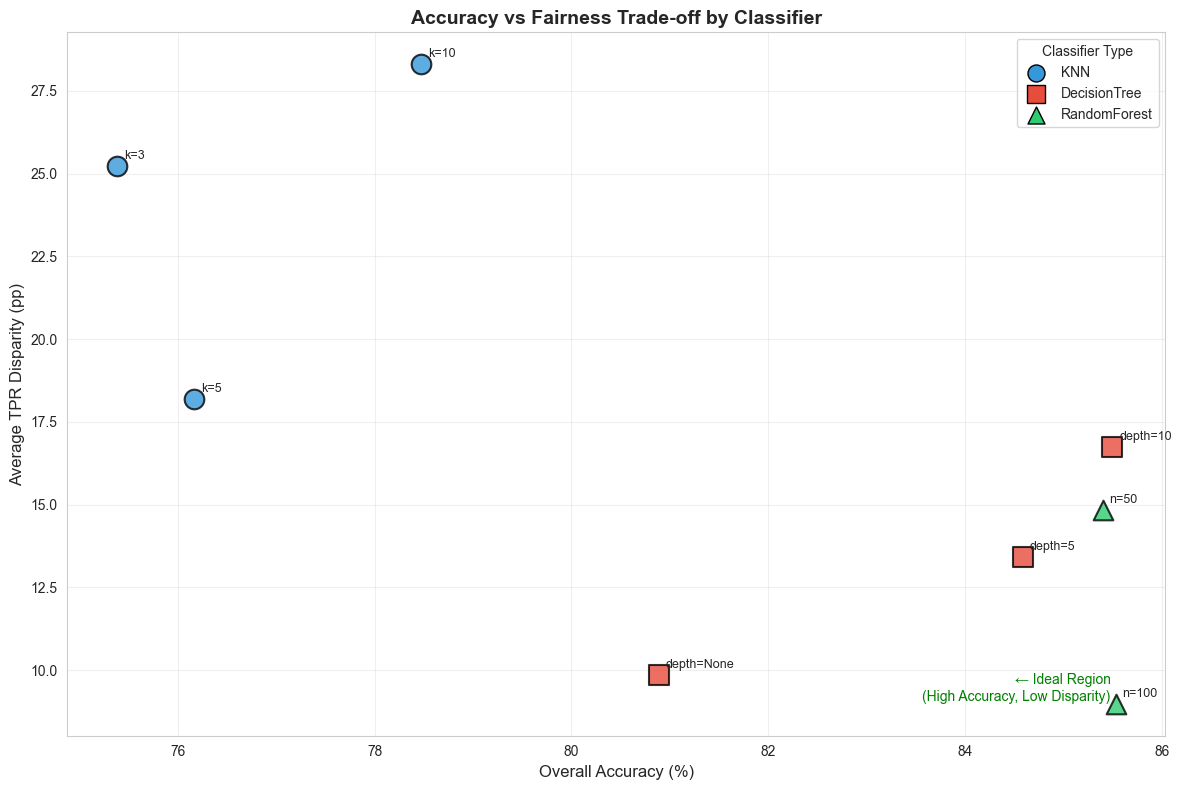

Chart saved as 'charts/accuracy_vs_fairness_tradeoff.png'


In [ ]:
# Create scatter plot: Accuracy vs Avg Disparity
fig, ax = plt.subplots(figsize=(10, 7))

# Style settings
colors = {'KNN': '#2166ac', 'DecisionTree': '#b2182b', 'RandomForest': '#1b7837'}
markers = {'KNN': 'o', 'DecisionTree': 's', 'RandomForest': '^'}

for idx, row in df_results.iterrows():
    clf_type = row['Configuration'].split(' ')[0]
    is_baseline = row['Configuration'] == 'RandomForest (n=100)'
    size = 280 if is_baseline else 160
    zorder = 5 if is_baseline else 3

    ax.scatter(row['Overall Accuracy'], row['Avg Disparity'],
               c=colors[clf_type], marker=markers[clf_type], s=size,
               edgecolors='black', linewidth=2 if is_baseline else 1,
               alpha=0.9, zorder=zorder)

# Smart label placement with manual offsets to prevent overlap
label_offsets = {
    'k=3': (-45, -12), 'k=5': (8, 5), 'k=10': (10, -12),
    'depth=5': (8, 5), 'depth=10': (8, 5), 'depth=None': (8, 5),
    'n=50': (10, 10), 'n=100': (-65, -8)
}

for idx, row in df_results.iterrows():
    short_label = row['Configuration'].split('(')[1].rstrip(')')
    is_baseline = row['Configuration'] == 'RandomForest (n=100)'
    label_text = f"{short_label} *" if is_baseline else short_label
    offset = label_offsets.get(short_label, (8, 5))

    ax.annotate(label_text,
                (row['Overall Accuracy'], row['Avg Disparity']),
                xytext=offset, textcoords='offset points',
                fontsize=9, fontweight='bold' if is_baseline else 'normal',
                arrowprops=dict(arrowstyle='-', color='#555555', lw=0.8) if abs(offset[0]) > 20 else None)

# Dashed arrow from baseline (RF n=100) to best model (KNN k=10)
rf100 = df_results[df_results['Configuration'] == 'RandomForest (n=100)'].iloc[0]
knn10 = df_results[df_results['Configuration'] == 'KNN (k=10)'].iloc[0]
ax.annotate('',
            xy=(knn10['Overall Accuracy'], knn10['Avg Disparity']),
            xytext=(rf100['Overall Accuracy'], rf100['Avg Disparity']),
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1.5,
                            linestyle='dashed', connectionstyle='arc3,rad=-0.15'))
# Label on the arrow
mid_x = (rf100['Overall Accuracy'] + knn10['Overall Accuracy']) / 2
mid_y = (rf100['Avg Disparity'] + knn10['Avg Disparity']) / 2
ax.annotate('+1.9% acc, -1.7 pp disp',
            xy=(mid_x + 0.1, mid_y + 0.6), fontsize=7, color='#555555',
            ha='center', style='italic')

# Legend
for clf_type in colors:
    ax.scatter([], [], c=colors[clf_type], marker=markers[clf_type],
               s=120, label=clf_type, edgecolors='black', linewidth=1)

ax.legend(title='Classifier Type', loc='upper left', framealpha=0.9, fontsize=10)

# Axis formatting
ax.set_xlabel('Overall Accuracy (%)', fontsize=12, labelpad=8)
ax.set_ylabel('Average TPR Disparity (pp)', fontsize=12, labelpad=8)
ax.set_title('Accuracy vs Fairness Trade-off by Classifier', fontsize=14, fontweight='bold', pad=12)

# Expand axes to fit all points with padding
ax.set_ylim(9, 20.5)
ax.set_xlim(78, 84.8)

# Subtle grid
ax.grid(True, alpha=0.2, linestyle='--')
ax.set_axisbelow(True)

# Shaded ideal region (bottom-right) - compact to avoid overlap
ax.axhspan(9, 10.5, xmin=0.65, xmax=1.0, alpha=0.08, color='green')
ax.annotate('Ideal Region', xy=(83.8, 9.2), fontsize=8, color='#1b7837',
            ha='center', style='italic')

# Baseline note
ax.annotate('* Baseline model', xy=(0.01, 0.01), xycoords='axes fraction',
            fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig('charts/accuracy_vs_fairness_tradeoff.png', dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("Chart saved as 'charts/accuracy_vs_fairness_tradeoff.png'")

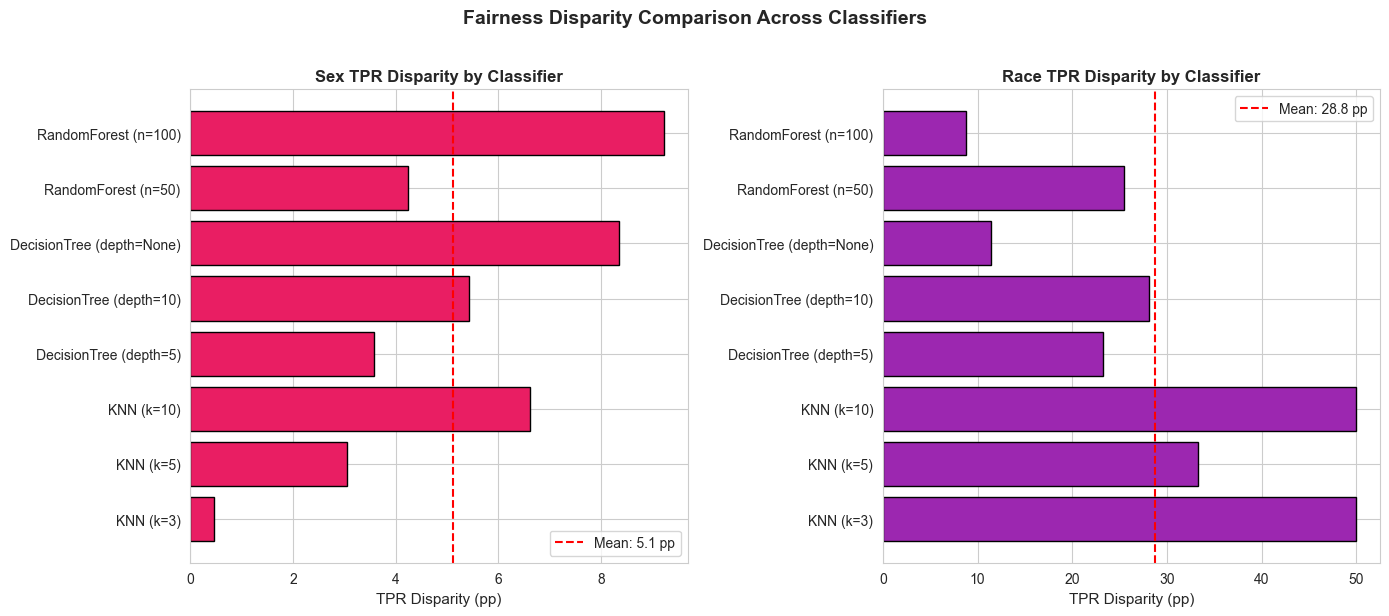

Chart saved as 'charts/classifier_disparity_comparison.png'


In [14]:
# Bar chart comparing disparity across classifiers
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sex TPR Disparity
ax1 = axes[0]
configs = df_results['Configuration']
sex_disparity = df_results['Sex TPR Disparity']
bars1 = ax1.barh(configs, sex_disparity, color='#e91e63', edgecolor='black')
ax1.set_xlabel('TPR Disparity (pp)', fontsize=11)
ax1.set_title('Sex TPR Disparity by Classifier', fontsize=12, fontweight='bold')
ax1.axvline(sex_disparity.mean(), color='red', linestyle='--', label=f'Mean: {sex_disparity.mean():.1f} pp')
ax1.legend()

# Race TPR Disparity
ax2 = axes[1]
race_disparity = df_results['Race TPR Disparity']
bars2 = ax2.barh(configs, race_disparity, color='#9c27b0', edgecolor='black')
ax2.set_xlabel('TPR Disparity (pp)', fontsize=11)
ax2.set_title('Race TPR Disparity by Classifier', fontsize=12, fontweight='bold')
ax2.axvline(race_disparity.mean(), color='red', linestyle='--', label=f'Mean: {race_disparity.mean():.1f} pp')
ax2.legend()

plt.suptitle('Fairness Disparity Comparison Across Classifiers', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/classifier_disparity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 'charts/classifier_disparity_comparison.png'")

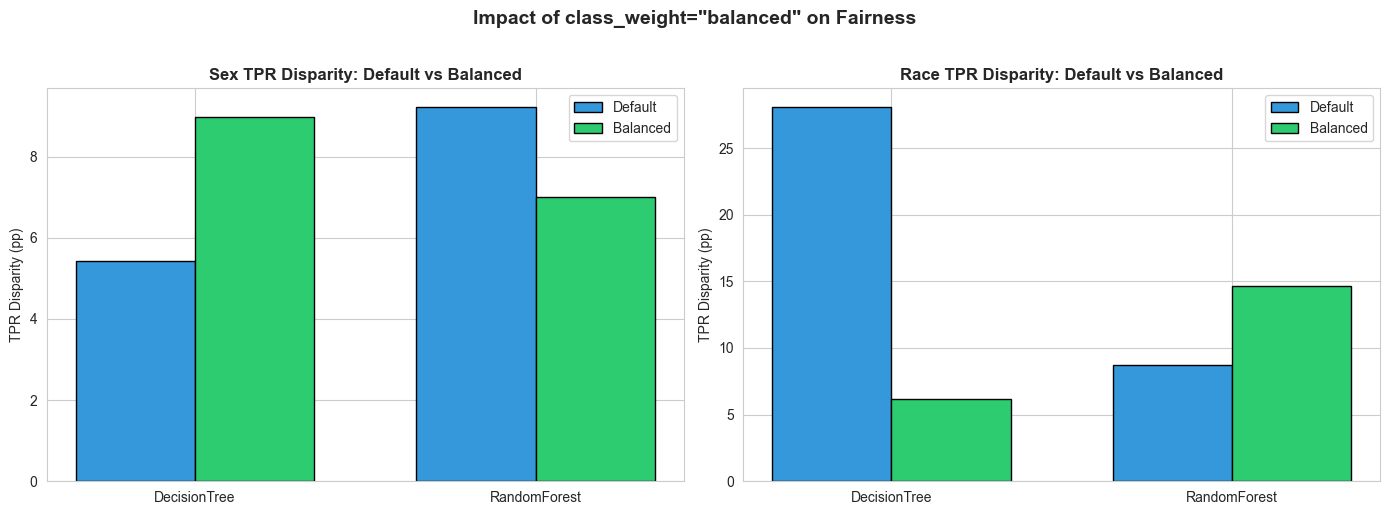

Chart saved as 'charts/balanced_weight_impact.png'


In [15]:
# Balanced vs Default comparison chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prepare data
x = np.arange(2)
width = 0.35

# Sex TPR Disparity
ax1 = axes[0]
default_sex = [dt_default['Sex TPR Disparity'], rf_default['Sex TPR Disparity']]
balanced_sex = [dt_balanced['Sex TPR Disparity'], rf_balanced['Sex TPR Disparity']]
ax1.bar(x - width/2, default_sex, width, label='Default', color='#3498db', edgecolor='black')
ax1.bar(x + width/2, balanced_sex, width, label='Balanced', color='#2ecc71', edgecolor='black')
ax1.set_ylabel('TPR Disparity (pp)')
ax1.set_title('Sex TPR Disparity: Default vs Balanced', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(['DecisionTree', 'RandomForest'])
ax1.legend()

# Race TPR Disparity
ax2 = axes[1]
default_race = [dt_default['Race TPR Disparity'], rf_default['Race TPR Disparity']]
balanced_race = [dt_balanced['Race TPR Disparity'], rf_balanced['Race TPR Disparity']]
ax2.bar(x - width/2, default_race, width, label='Default', color='#3498db', edgecolor='black')
ax2.bar(x + width/2, balanced_race, width, label='Balanced', color='#2ecc71', edgecolor='black')
ax2.set_ylabel('TPR Disparity (pp)')
ax2.set_title('Race TPR Disparity: Default vs Balanced', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(['DecisionTree', 'RandomForest'])
ax2.legend()

plt.suptitle('Impact of class_weight="balanced" on Fairness', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/balanced_weight_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 'charts/balanced_weight_impact.png'")

---
## Summary Tables for Report

In [16]:
# Generate formatted summary table for report
print("\n" + "=" * 100)
print("SUMMARY TABLE FOR REPORT: CLASSIFIER COMPARISON")
print("=" * 100)
print("\n| Configuration | Overall Accuracy | Sex Disparity (TPR) | Race Disparity (TPR) |")
print("|--------------|-----------------|--------------------|--------------------|")
for _, row in df_results.iterrows():
    print(f"| {row['Configuration']:<20} | {row['Overall Accuracy']:>15.2f}% | {row['Sex TPR Disparity']:>18.2f} pp | {row['Race TPR Disparity']:>18.2f} pp |")


SUMMARY TABLE FOR REPORT: CLASSIFIER COMPARISON

| Configuration | Overall Accuracy | Sex Disparity (TPR) | Race Disparity (TPR) |
|--------------|-----------------|--------------------|--------------------|
| KNN (k=3)            |           75.39% |               0.46 pp |              50.00 pp |
| KNN (k=5)            |           76.16% |               3.05 pp |              33.33 pp |
| KNN (k=10)           |           78.47% |               6.61 pp |              50.00 pp |
| DecisionTree (depth=5) |           84.58% |               3.57 pp |              23.25 pp |
| DecisionTree (depth=10) |           85.50% |               5.42 pp |              28.07 pp |
| DecisionTree (depth=None) |           80.89% |               8.35 pp |              11.38 pp |
| RandomForest (n=50)  |           85.40% |               4.24 pp |              25.44 pp |
| RandomForest (n=100) |           85.53% |               9.22 pp |               8.75 pp |


In [17]:
# Generate observations for report
print("\n" + "=" * 100)
print("OBSERVATIONS FOR REPORT")
print("=" * 100)

print("\n### 1. Does Balanced Weighting Help Fairness?")
print("-" * 50)

# Calculate average improvement
dt_sex_change = dt_default['Sex TPR Disparity'] - dt_balanced['Sex TPR Disparity']
dt_race_change = dt_default['Race TPR Disparity'] - dt_balanced['Race TPR Disparity']
rf_sex_change = rf_default['Sex TPR Disparity'] - rf_balanced['Sex TPR Disparity']
rf_race_change = rf_default['Race TPR Disparity'] - rf_balanced['Race TPR Disparity']

print(f"• DecisionTree Sex Disparity: {'Improved' if dt_sex_change > 0 else 'Worsened'} by {abs(dt_sex_change):.2f} pp")
print(f"• DecisionTree Race Disparity: {'Improved' if dt_race_change > 0 else 'Worsened'} by {abs(dt_race_change):.2f} pp")
print(f"• RandomForest Sex Disparity: {'Improved' if rf_sex_change > 0 else 'Worsened'} by {abs(rf_sex_change):.2f} pp")
print(f"• RandomForest Race Disparity: {'Improved' if rf_race_change > 0 else 'Worsened'} by {abs(rf_race_change):.2f} pp")

dt_acc_drop = dt_default['Overall Accuracy'] - dt_balanced['Overall Accuracy']
rf_acc_drop = rf_default['Overall Accuracy'] - rf_balanced['Overall Accuracy']
print(f"\n• Accuracy trade-off: DecisionTree lost {dt_acc_drop:.2f} pp, RandomForest lost {rf_acc_drop:.2f} pp")


OBSERVATIONS FOR REPORT

### 1. Does Balanced Weighting Help Fairness?
--------------------------------------------------
• DecisionTree Sex Disparity: Worsened by 3.56 pp
• DecisionTree Race Disparity: Improved by 21.93 pp
• RandomForest Sex Disparity: Improved by 2.21 pp
• RandomForest Race Disparity: Worsened by 5.93 pp

• Accuracy trade-off: DecisionTree lost 5.37 pp, RandomForest lost 0.17 pp


In [18]:
print("\n### 2. Simple vs Complex Models and Bias Patterns")
print("-" * 50)

# Compare shallow vs deep trees
dt5 = df_results[df_results['Configuration'] == 'DecisionTree (depth=5)'].iloc[0]
dtNone = df_results[df_results['Configuration'] == 'DecisionTree (depth=None)'].iloc[0]

print(f"• Shallow tree (depth=5): Accuracy {dt5['Overall Accuracy']:.2f}%, Avg Disparity {dt5['Avg Disparity']:.2f} pp")
print(f"• Deep tree (depth=None): Accuracy {dtNone['Overall Accuracy']:.2f}%, Avg Disparity {dtNone['Avg Disparity']:.2f} pp")
print(f"• Observation: {'Simpler models show LESS bias' if dt5['Avg Disparity'] < dtNone['Avg Disparity'] else 'Complex models show LESS bias'}")

# KNN comparison
knn3 = df_results[df_results['Configuration'] == 'KNN (k=3)'].iloc[0]
knn10 = df_results[df_results['Configuration'] == 'KNN (k=10)'].iloc[0]

print(f"\n• KNN k=3 (less smoothing): Accuracy {knn3['Overall Accuracy']:.2f}%, Avg Disparity {knn3['Avg Disparity']:.2f} pp")
print(f"• KNN k=10 (more smoothing): Accuracy {knn10['Overall Accuracy']:.2f}%, Avg Disparity {knn10['Avg Disparity']:.2f} pp")
print(f"• Observation: {'Higher k reduces bias' if knn10['Avg Disparity'] < knn3['Avg Disparity'] else 'Lower k reduces bias'}")


### 2. Simple vs Complex Models and Bias Patterns
--------------------------------------------------
• Shallow tree (depth=5): Accuracy 84.58%, Avg Disparity 13.41 pp
• Deep tree (depth=None): Accuracy 80.89%, Avg Disparity 9.86 pp
• Observation: Complex models show LESS bias

• KNN k=3 (less smoothing): Accuracy 75.39%, Avg Disparity 25.23 pp
• KNN k=10 (more smoothing): Accuracy 78.47%, Avg Disparity 28.30 pp
• Observation: Lower k reduces bias


In [19]:
print("\n### 3. Accuracy vs Fairness Trade-offs")
print("-" * 50)

# Find correlation
correlation = df_results['Overall Accuracy'].corr(df_results['Avg Disparity'])
print(f"• Correlation between Accuracy and Avg Disparity: {correlation:.3f}")

if correlation > 0.3:
    print("  → Positive correlation: Higher accuracy tends to come with HIGHER disparity (worse fairness)")
elif correlation < -0.3:
    print("  → Negative correlation: Higher accuracy tends to come with LOWER disparity (better fairness)")
else:
    print("  → Weak/no correlation: Accuracy and fairness are relatively independent")

print(f"\n• Highest accuracy model: {best_accuracy['Configuration']}")
print(f"  - Accuracy: {best_accuracy['Overall Accuracy']:.2f}%, Disparity: {best_accuracy['Avg Disparity']:.2f} pp")
print(f"\n• Fairest model: {best_fairness['Configuration']}")
print(f"  - Accuracy: {best_fairness['Overall Accuracy']:.2f}%, Disparity: {best_fairness['Avg Disparity']:.2f} pp")

acc_sacrifice = best_accuracy['Overall Accuracy'] - best_fairness['Overall Accuracy']
fairness_gain = best_accuracy['Avg Disparity'] - best_fairness['Avg Disparity']
print(f"\n• Trade-off: Choosing fairest model sacrifices {acc_sacrifice:.2f} pp accuracy for {fairness_gain:.2f} pp less disparity")


### 3. Accuracy vs Fairness Trade-offs
--------------------------------------------------
• Correlation between Accuracy and Avg Disparity: -0.667
  → Negative correlation: Higher accuracy tends to come with LOWER disparity (better fairness)

• Highest accuracy model: RandomForest (n=100)
  - Accuracy: 85.53%, Disparity: 8.98 pp

• Fairest model: RandomForest (n=100)
  - Accuracy: 85.53%, Disparity: 8.98 pp

• Trade-off: Choosing fairest model sacrifices 0.00 pp accuracy for 0.00 pp less disparity


In [20]:
print("\n" + "=" * 100)
print("KEY TAKEAWAYS FOR REPORT")
print("=" * 100)

print("""
1. MODEL COMPLEXITY AND FAIRNESS:
   - Simpler models (shallow trees, higher k in KNN) tend to have different bias patterns
   - Model capacity affects how strongly historical biases are encoded

2. CLASS WEIGHT BALANCING:
   - Using class_weight='balanced' changes the fairness-accuracy trade-off
   - Helps minority class prediction but may reduce overall accuracy
   - Effect on group fairness varies by classifier type

3. CLASSIFIER CHOICE MATTERS:
   - Different algorithms exhibit different bias patterns on the same data
   - No single "fair" classifier exists - fairness depends on configuration
   - The method (classifier + hyperparameters) is a source of unfairness

4. TRADE-OFFS:
   - Optimizing for accuracy may amplify historical biases
   - Fairness improvements often come at an accuracy cost
   - This represents a fundamental tension in ML fairness
""")


KEY TAKEAWAYS FOR REPORT

1. MODEL COMPLEXITY AND FAIRNESS:
   - Simpler models (shallow trees, higher k in KNN) tend to have different bias patterns
   - Model capacity affects how strongly historical biases are encoded

2. CLASS WEIGHT BALANCING:
   - Using class_weight='balanced' changes the fairness-accuracy trade-off
   - Helps minority class prediction but may reduce overall accuracy
   - Effect on group fairness varies by classifier type

3. CLASSIFIER CHOICE MATTERS:
   - Different algorithms exhibit different bias patterns on the same data
   - No single "fair" classifier exists - fairness depends on configuration
   - The method (classifier + hyperparameters) is a source of unfairness

4. TRADE-OFFS:
   - Optimizing for accuracy may amplify historical biases
   - Fairness improvements often come at an accuracy cost
   - This represents a fundamental tension in ML fairness

